In [435]:
from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

sns.set_palette("husl")

g = plots.get_subplot_plotter(width_inch=7)
g.settings.axes_fontsize=15
g.settings.axes_labelsize=15
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 15

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/glass_mock_chains/"

index = 200
n_contours = 4
roots = [
    f"glass_mock_v0_{i:05d}" for i in range(index, index + n_contours)
]

print(roots)

['glass_mock_v0_00200', 'glass_mock_v0_00201', 'glass_mock_v0_00202', 'glass_mock_v0_00203']


In [436]:
# MAKE PARAMNAMES FILE

for root in roots:
    with open(root_dir + '{}/{}/samples_{}.txt'.format('/'+root ,root, root), "r") as file:
        params = file.readline()[1:].split('\t')[:-4]
        file.close()
 
    with open(root_dir + '{}/{}/getdist_{}.paramnames'.format('/'+root, root, root), "w") as file:
        for i in range(len(params)):
            if len(params[i].split('--')) > 1:
                file.write(params[i].split('--')[1] + '\n')
            else:
                file.write(params[i].split('--')[0] + '\n')
        file.close()

    with open(root_dir + '{}/{}/samples_{}_cell.txt'.format('/'+root ,root, root), "r") as file:
        params = file.readline()[1:].split('\t')[:-4]
        file.close()
 
    with open(root_dir + '{}/{}/getdist_{}_cell.paramnames'.format('/'+root, root, root), "w") as file:
        for i in range(len(params)):
            if len(params[i].split('--')) > 1:
                file.write(params[i].split('--')[1] + '\n')
            else:
                file.write(params[i].split('--')[0] + '\n')
        file.close()

In [437]:
#READ CHAIN

chains=[]

for root in roots:

    samples = np.loadtxt(root_dir + '{}/{}/samples_{}.txt'.format(root,root, root))
    print(len(samples))
    if 'nautilus' in root:
        samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
    else:
        samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
    np.savetxt(root_dir + '{}/{}/getdist_{}.txt'.format(root,root, root), samples)
    
    chain = g.samples_for_root(root_dir + '{}/{}/getdist_{}'.format(root,root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

    samples = np.loadtxt(root_dir + '{}/{}/samples_{}_cell.txt'.format(root,root,root))
    print(len(samples))
    if 'nautilus' in root:
        samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
    else:
        samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
    np.savetxt(root_dir + '{}/{}/getdist_{}_cell.txt'.format(root,root,root), samples)
    
    chain = g.samples_for_root(root_dir + '{}/{}/getdist_{}_cell'.format(root,root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

2188
/n09data/guerrini/glass_mock_chains/glass_mock_v0_00200/glass_mock_v0_00200/getdist_glass_mock_v0_00200.txt
Removed no burn in
1692
/n09data/guerrini/glass_mock_chains/glass_mock_v0_00200/glass_mock_v0_00200/getdist_glass_mock_v0_00200_cell.txt
Removed no burn in
2135
/n09data/guerrini/glass_mock_chains/glass_mock_v0_00201/glass_mock_v0_00201/getdist_glass_mock_v0_00201.txt
Removed no burn in
1648
/n09data/guerrini/glass_mock_chains/glass_mock_v0_00201/glass_mock_v0_00201/getdist_glass_mock_v0_00201_cell.txt
Removed no burn in
2029
/n09data/guerrini/glass_mock_chains/glass_mock_v0_00202/glass_mock_v0_00202/getdist_glass_mock_v0_00202.txt
Removed no burn in
1872
/n09data/guerrini/glass_mock_chains/glass_mock_v0_00202/glass_mock_v0_00202/getdist_glass_mock_v0_00202_cell.txt
Removed no burn in
2017
/n09data/guerrini/glass_mock_chains/glass_mock_v0_00203/glass_mock_v0_00203/getdist_glass_mock_v0_00203.txt
Removed no burn in
1796
/n09data/guerrini/glass_mock_chains/glass_mock_v0_00203/

In [438]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1']
label_list = ['\Omega_m', '\omega_b h^2', 'h_0', 'n_s', '\sigma_8', 'S_8', 'log T_{AGN}', 'A_{IA}', 'm_1', '\Delta z_1']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        param_names.parWithName(name).label = label

In [439]:
from astropy.cosmology import Planck18 as planck

Omega_m_fid = planck.Om0
sigma_8_fid = 0.8054
s8_fid = sigma_8_fid * (Omega_m_fid / 0.3)**0.5
h = planck.h
Omega_b_fig = planck.Ob0
n_s_fid = 0.965
print(f"Fiducial values: Omega_m = {Omega_m_fid}, sigma_8 = {sigma_8_fid}, S_8 = {s8_fid}")

markers = {
    "OMEGA_M": Omega_m_fid,
    "SIGMA_8": sigma_8_fid,
    "s_8_input": s8_fid,
    "h0": h,
    "ombh2": Omega_b_fig * h**2,
    "n_s": n_s_fid
}

Fiducial values: Omega_m = 0.30966, sigma_8 = 0.8054, S_8 = 0.818264203635965


In [440]:
legend_labels = [
     label
    for i in range(index, index + n_contours)
    for label in (
        rf"$\xi_\pm(\vartheta)$, GLASS mock {i}",
        rf"$C_\ell$, GLASS mock {i}"
    )
]

""" 
#Plot all parameters
g.triangle_plot(
    chains,
    ['OMEGA_M','ombh2', 'h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    filled=True,
    markers=markers
)

plt.show() """

" \n#Plot all parameters\ng.triangle_plot(\n    chains,\n    ['OMEGA_M','ombh2', 'h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1'],\n    legend_labels=legend_labels,\n    legend_loc='upper right',\n    filled=True,\n    markers=markers\n)\n\nplt.show() "

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


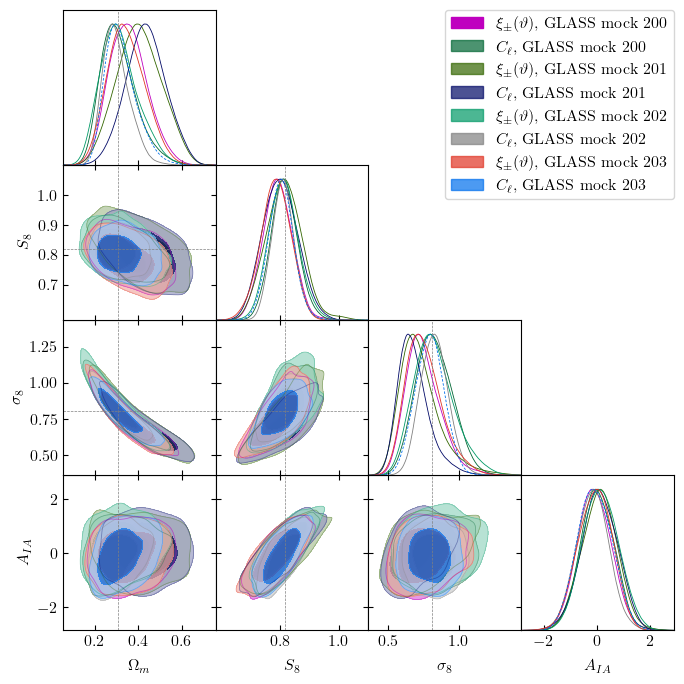

In [441]:
#Plot only cosmological parameters

g.triangle_plot(
    chains,
    ['OMEGA_M','s_8_input', 'SIGMA_8', 'a'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    filled=True,
    markers=markers
)


plt.show()

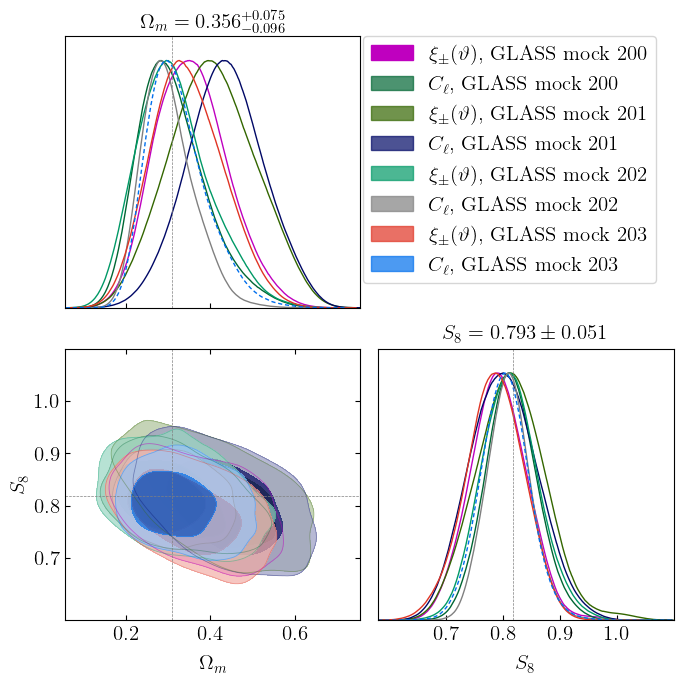

In [442]:
preliminary_watermark = False
#Plot S8 Omega_m only
g.triangle_plot(
    chains,
    ['OMEGA_M','s_8_input'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    filled=True,
    title_limit=1,
    markers=markers
)

if preliminary_watermark:
    plt.figtext(0.5, 0.5, 'PRELIMINARY',
            fontsize=150, color='gray',
            ha='center', va='center',
            alpha=0.3, rotation=330)

plt.show()